<a href="https://colab.research.google.com/github/prasad2154/NewVision/blob/main/Machine_learning/Decision_Tree_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [ ]:
# 2. Load Dataset
# ==========================================

df = pd.read_csv("banknotes (1).csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (1372, 5)

Columns:
Index(['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class'], dtype='object')

First 5 Rows:
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
#  3. Basic Data Analysis
# ==========================================

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

print("\nClass Distribution:")
print(df['Class'].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

Statistical Summary:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6

In [ ]:

# 4. Separate X and y
# ==========================================

X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
# 5. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (1097, 4)
Testing Data: (275, 4)


In [ ]:
# 6. Create Decision Tree
# ==========================================

dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)



In [ ]:
# 7. Train Model
# ==========================================

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# 8. Prediction
# ==========================================

y_pred = dt_model.predict(X_test)
y_pred


array([0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0])

In [ ]:
# 9. Performance Metrics
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")



MODEL PERFORMANCE
Accuracy  : 0.9927
Precision : 0.9839
Recall    : 1.0000
F1 Score  : 0.9919


In [ ]:
# 10. Classification Report
# ==========================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275




Confusion Matrix:
[[151   2]
 [  0 122]]


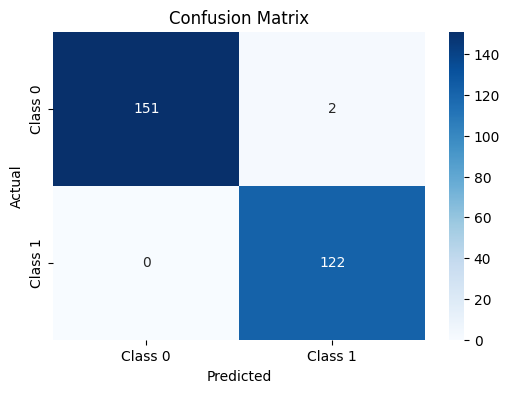

In [ ]:
# 11. Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 12. ROC-AUC
# ==========================================

y_prob = dt_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9934640522875817


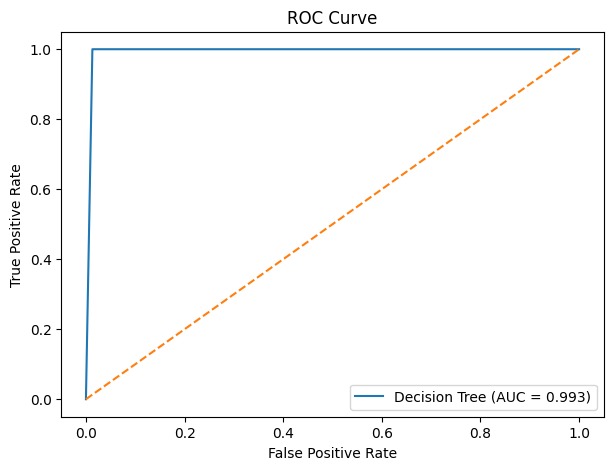

In [ ]:
# 13. ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


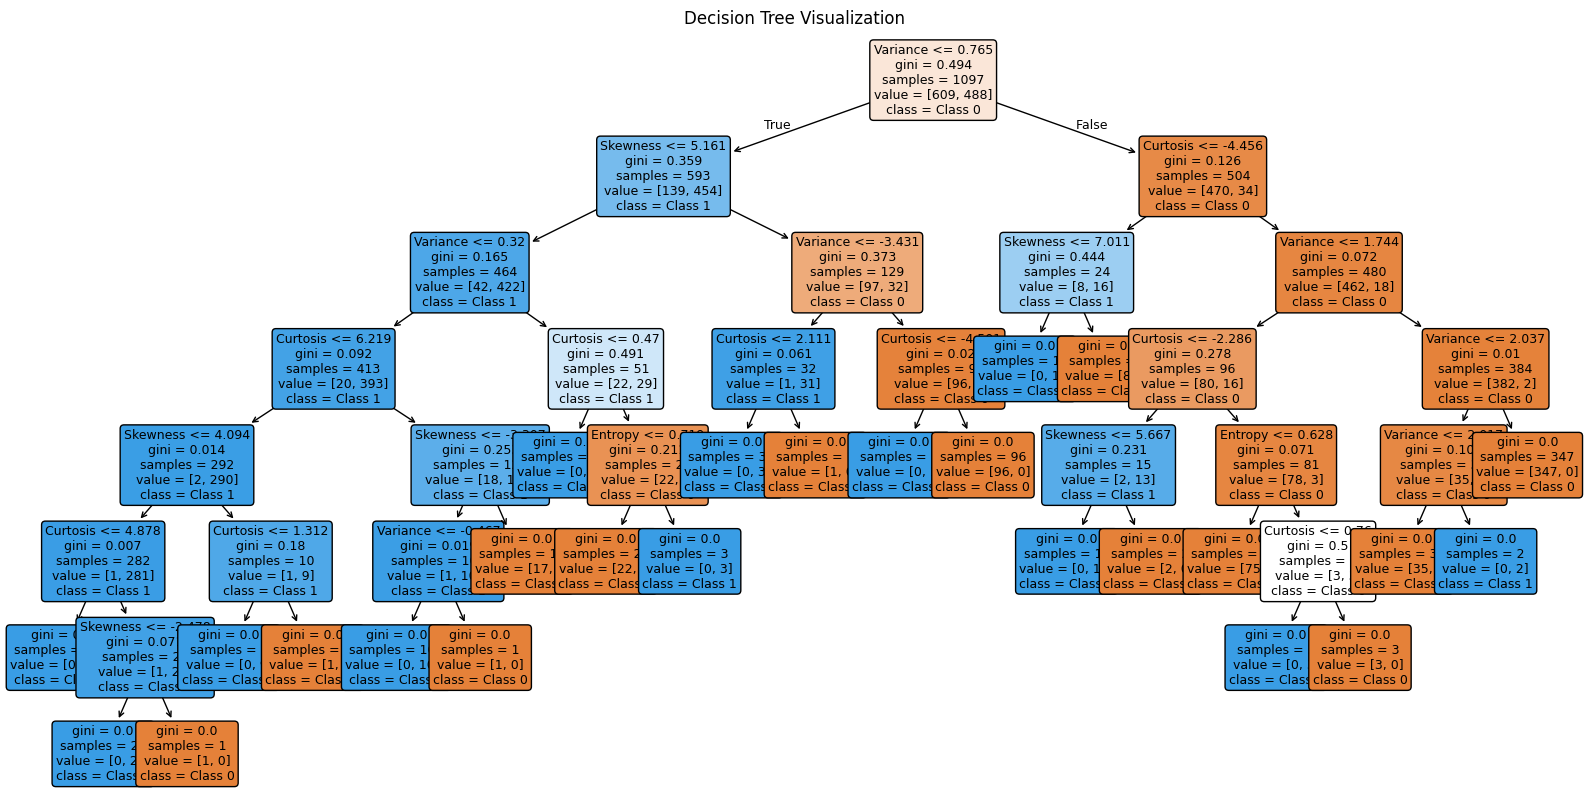

In [ ]:
# 15. Decision Tree Visualization
# ==========================================

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Class 0', 'Class 1'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Visualization")
plt.show()


# ===========

In [ ]:
# 16. Tree Information
# ==========================================

print("\nTree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())
print("Number of Nodes:", dt_model.tree_.node_count)



Tree Depth: 7
Number of Leaves: 25
Number of Nodes: 49


In [ ]:
# 17. Cross Validation
# ==========================================

cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Scores:")
print(cv_scores)

print("Mean CV Accuracy:",
      cv_scores.mean())



Cross Validation Scores:
[0.98909091 0.97090909 0.97445255 0.98540146 0.98540146]
Mean CV Accuracy: 0.981051094890511


In [ ]:
# 18. Hyperparameter Tuning
# ==========================================

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
 # 21. Final Performance
# ==========================================

print("\n================================")
print("FINAL TUNED MODEL PERFORMANCE")
print("================================")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


FINAL TUNED MODEL PERFORMANCE
Accuracy: 0.9927272727272727
Precision: 0.9838709677419355
Recall: 1.0
F1 Score: 0.991869918699187

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [ ]:
# ==========================================
# 20. Final Tuned Model
# ==========================================

best_dt_model = grid_search.best_estimator_

y_pred_best = best_dt_model.predict(X_test)


In [ ]:
# 22. Save Final Model
# ==========================================

joblib.dump(
    dt_model,
    "decision_tree_model.pkl"
)

print("\nModel saved successfully!")


Model saved successfully!
